## 回归作为一次函数实现
1. 核心是用批量梯度下降(BGD)算法，从CSV数据中拟合出来一条直线，来描述自变量x和因变量y之间的线性关系

2. Pandas库：数据读取与处理，用于读取csv文件，处理表格型数据，是数据分析的常用工具

3. with open()读取文件：用上下文管理器with打来文件，好处是代码结束后会自动关闭文件，避免资源泄漏

4. encoding='utf-8':指定文件编码，防止中文/特殊字符乱码

5. pd.read_csv()读取csv数据：pandas 的 read_csv 可以直接把CSV文件读成DataFrame（表格型数据结构），方便后续处理

6. 数据拆分： train['x'].values:从DataFrame中提取x列，转为numpy数组，取为自变量。
    同理 train['y'].values 提取y列，转为numpy数组，作为因变量

7. 标准化：
        作用：统一特征尺度，加速梯度下降收敛
        公式：$$z = \frac{x-\mu}{\sigma}$$
          $\mu$ ：特征的均值（np.mean(train_x)）
          $\sigma$ ：特征的标准差（np.std(train_x)）

8. np.random.rand(1) ：生成一个[0,1)之间的随机数，作为参数的初始值。梯度下降需要从初始值开始迭代，随机初始化可以避免固定初始值带来的
   偏差。

9. 损失函数定义：公式：$$E(\theta_0,\theta_1)=\frac12\sum_{i=1}^n\big(y_i - (\theta_0+\theta_1 x_i)\big)^2$$

10. 损失函数对参数的梯度为：公式：
$$
\begin{cases}
\theta_0 = \theta_0 - \alpha \displaystyle\sum_{i=1}^n \big(f(x_i)-y_i\big)\\[6pt]
\theta_1 = \theta_1 - \alpha \displaystyle\sum_{i=1}^n \big(f(x_i)-y_i\big)x_i
\end{cases}
$$



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# 1.读取数据，拆分自变量x、因变量y
with open('reg_data.csv', encoding='utf-8') as f:
    print("文件内容：")
    print(f.read())
train=pd.read_csv('reg_data.csv')
print(train.shape)
train_x=train['x'].values
train_y=train['y'].values
# 3.数据标准化
mu=np.mean(train_x)
sigma=np.std(train_x)
def standardize(x):
    return (x-mu)/sigma
train_z=standardize(train_x)
#4.初始化模型参数（随机赋初值）
theta0=np.random.rand(1)
theta1=np.random.rand(1)
#5.设定超参数（学习率，收敛赋值）
ETA=1e-3
diff=1
#6.确定模型公式
def f(x):
    return (theta0+theta1*x)
#7.定义损失函数
def E(x,y):
    return 0.5*np.sum((y-f(x))**2)
error=E(train_z,train_y)
#8. 批量梯度下降参数更新（同步更新）
count=0
while diff>1e-3:
    tmp_theta0=theta0-ETA*np.sum(f(train_z)-train_y)
    tmp_theta1=theta1-ETA*np.sum((f(train_z)-train_y)*train_z)
    theta0=tmp_theta0
    theta1=tmp_theta1
    #迭代训练流程
    current_error=E(train_z,train_y)
    diff=abs(error-current_error)
    error=current_error
    #输出日志
    count += 1
    log='第{}次：theta0={:.3f},theta1={:.3f},差值={:.4f}'
    print(log.format(count,float(theta0),float(theta1),float(diff)))
#确认绘图
x=np.linspace(-3,3,100)
plt.plot(train_z,train_y,'o')
plt.plot(x,f(x))
plt.show()

## 多项式回归的实现（以二项式为例）
1. 二次函数都有三个参数：
                    np.random.rand(3)：生成三个0-1，随机数作为初始权重
                    公式：$$\hat y_i = \theta_0 + \theta_1 x_i + \theta_2 x_i^2$$
                    
2. 构造多项式特征矩阵： np.vstack()竖直拼接， .T 矩阵转置
                    公式：
$$
X=
\begin{bmatrix}
1 & x_1 & x_1^2\\
1 & x_2 & x_2^2\\
\vdots & \vdots & \vdots
\end{bmatrix}
$$
3. 批量梯度下降更新公式：
$$\boldsymbol{\theta} = \boldsymbol{\theta} - \alpha \cdot X^\mathrm{T}(\hat{\boldsymbol{y}}-\boldsymbol{y})$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
with open('reg_data.csv',encoding='utf-8') as f:
    f.read()
train=pd.read_csv('reg_data.csv')
train_x=train['x'].values
train_y=train['y'].values
#初始化参数
theta=np.random.rand(3)
#创建训练数据的矩阵
def to_matrix(x):
    return np.vstack([np.ones(len(x)),x,x**2]).T
#预测函数
def f(x):
    return np.dot(x,theta)
#实现标准化
def standardize(x):
    mu=np.mean(x)
    sigma=np.std(x)
    return (x-mu)/sigma
train_z=standardize(train_x)
X=to_matrix(train_z)
#定义损失函数
def E(x,y):
    return 0.5*np.sum((y-f(x))**2)
#定义超参数值
ETA=1e-3
diff=1
count=0
error=E(X,train_y)
while diff>1e-3:
    #更新参数
    theta=theta-ETA*np.dot(f(X)-train_y,X)
    #计算上次误差的差值
    current_error=E(X,train_y)
    diff=abs(error-current_error)
    error=current_error
    #输出日志
    count += 1
    log='第{}次：theta1={:.3f},theta2={:.3f},theta3={:.3f},差值={:.4f}'
    print(log.format(count,float(theta[0]),float(theta[1]),float(theta[2]),float(diff)))
x=np.linspace(-3,3,100)
plt.plot(train_z,train_y,'bo')
plt.plot(train_z,f(X),'r-')
plt.show()



## 随机梯度下降（SGD）
1. 批量梯度下降和随机梯度下降比较：
   批量梯度下降分项更新公式：
$$
\begin{cases}
\theta_0=\theta_0-\alpha\displaystyle\sum_{i=1}^n(\hat y_i-y_i)\\[6pt]
\theta_1=\theta_1-\alpha\displaystyle\sum_{i=1}^n(\hat y_i-y_i)x_i\\[6pt]
\theta_2=\theta_2-\alpha\displaystyle\sum_{i=1}^n(\hat y_i-y_i)x_i^2
\end{cases}
$$
   随机梯度下降分项更新公式：
$$
\begin{cases}
\theta_0=\theta_0-\alpha(\hat y_i-y_i)\\[6pt]
\theta_1=\theta_1-\alpha(\hat y_i-y_i)x_i\\[6pt]
\theta_2=\theta_2-\alpha(\hat y_i-y_i)x_i^2
\end{cases}
$$
## 批量梯度下降和随机梯度下降核心区别总结
 
1. 样本范围
BGD：求和，用全体数据
SGD：无求和，只用单条数据i

2. 更新频率
BGD：遍历全集 → 更新1次
SGD：遍历1条 → 更新1次

3. 收敛形态
BGD：平滑直线下降
SGD：震荡曲折下降

2. np.random.permutation() ：作用：生成随机乱序索引，打乱训练集顺序
                             目的：避免模型按固定顺序学习，防止拟合偏向性
                             SCD必须加，BGD不需要打乱顺序

3. MSE均方误差函数：公式：
$$MSE=\frac1n\sum_{i=1}^n(y_i-\hat y_i)^2$$
SGD训练习惯用标准均方误差MSE监控收敛


第1次：theta1=0.582,theta2=0.888,theta3=0.675,差值=3.8006
第2次：theta1=0.675,theta2=0.933,theta3=0.762,差值=3.6410
第3次：theta1=0.766,theta2=0.978,theta3=0.847,差值=3.4831
第4次：theta1=0.855,theta2=1.023,theta3=0.929,差值=3.3308
第5次：theta1=0.942,theta2=1.067,theta3=1.009,差值=3.1912
第6次：theta1=1.028,theta2=1.111,theta3=1.086,差值=3.0502
第7次：theta1=1.112,theta2=1.155,theta3=1.162,差值=2.9256
第8次：theta1=1.195,theta2=1.197,theta3=1.235,差值=2.7980
第9次：theta1=1.276,theta2=1.240,theta3=1.306,差值=2.6833
第10次：theta1=1.356,theta2=1.282,theta3=1.375,差值=2.5697
第11次：theta1=1.434,theta2=1.323,theta3=1.442,差值=2.4597
第12次：theta1=1.511,theta2=1.365,theta3=1.508,差值=2.3572
第13次：theta1=1.586,theta2=1.406,theta3=1.571,差值=2.2602
第14次：theta1=1.660,theta2=1.446,theta3=1.632,差值=2.1647
第15次：theta1=1.732,theta2=1.486,theta3=1.692,差值=2.0763
第16次：theta1=1.804,theta2=1.526,theta3=1.749,差值=1.9859
第17次：theta1=1.874,theta2=1.565,theta3=1.805,差值=1.9111
第18次：theta1=1.942,theta2=1.604,theta3=1.859,差值=1.8303
第19次：theta1=2.010,theta2=1.642,theta3

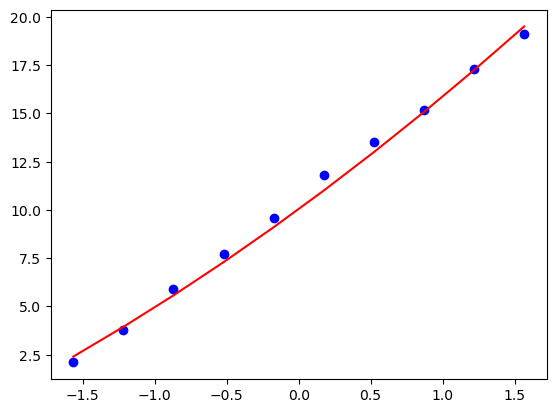

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
with open('reg_data.csv',encoding='utf-8') as f:
    f.read()
train=pd.read_csv('reg_data.csv')
train_x=train['x'].values
train_y=train['y'].values
#初始化参数
theta=np.random.rand(3)
def to_matrix(x):
    return np.vstack([np.ones(len(x)),x,x**2]).T
#预测函数
def f(x):
    return np.dot(x,theta)
#实现标准化
def standardize(x):
    mu=np.mean(x)
    sigma=np.std(x)
    return (x-mu)/sigma
train_z=standardize(train_x)
X=to_matrix(train_z)
#定义损失函数
def E(x,y):
    return 0.5*np.sum((y-f(x))**2)
#定义超参数值
ETA=1e-3
diff=1
count=0
#均方误差
def MSE(x,y):
    return (1/x.shape[0])*np.sum((y-f(x))**2)
#均方误差的历史记录
errors=[]
diff=1
errors.append(MSE(X,train_y))
while diff>1e-3:
    #为了调整寻训练数据的顺序，准备随机的序列
    p=np.random.permutation(X.shape[0])
    #随机取出训练数据，使用随机梯度下降法更新参数
    for x,y in zip(X[p,:],train_y[p]):
        theta=theta-ETA*((f(x)-y)*x)
    #计算与上一次误差的差值
    errors.append(MSE(X,train_y))
    diff=abs(errors[-2]-errors[-1])
    count+=1
    log='第{}次：theta1={:.3f},theta2={:.3f},theta3={:.3f},差值={:.4f}'
    print(log.format(count,float(theta[0]),float(theta[1]),float(theta[2]),float(diff)))
x=np.linspace(-3,3,100)
plt.plot(train_z,train_y,'bo')
plt.plot(train_z,f(X),'r-')
plt.show()
